# VaR y TailVaR — Presente e Histórico

Este notebook calcula las siguientes métricas de riesgo para la cartera real:

| Métrica | Método | Descripción |
|---------|--------|-------------|
| **VaR** | Paramétrico | Distribución normal escalada al horizonte |
| **TailVaR / CVaR** | Paramétrico | Expected Shortfall bajo normalidad |
| **VaR** | Histórico | Percentil empírico de retornos acumulados |
| **TailVaR / CVaR** | Histórico | Media de pérdidas en la cola empírica |

Se calculan tanto a **fecha presente** como su **evolución histórica** (rolling).

**Horizonte temporal: 1 semana (5 días de trading).**

In [ ]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ===========================================================================
# Configuración
# ===========================================================================
import importlib
import sys
import os

import numpy as np
import pandas as pd

# En Jupyter, __file__ no existe → usamos el directorio de trabajo actual.
# Ejecuta el notebook DESDE la carpeta Monitoring (cd Monitoring && jupyter notebook)
# o ajusta la ruta manualmente si lo abres desde otro sitio.
monitoring_dir = os.getcwd()   # directorio actual al lanzar Jupyter
if monitoring_dir not in sys.path:
    sys.path.insert(0, monitoring_dir)

import auxfun
import var_funciones as vf
importlib.reload(auxfun)
importlib.reload(vf)

# ---------------------------------------------------------------------------
# Parámetros globales
# ---------------------------------------------------------------------------
# Ruta al Excel de operaciones (relativa al directorio Monitoring)
# En Mac/Linux usamos '/' como separador
PATH_OPERATIVA = os.path.join(monitoring_dir, "..", "Envíos", "historico_operativa.xlsx")

CAPITAL        = 10_000_000   # capital inicial en €
FECHA_FIN      = None         # None = hoy
HOJA           = "Operativa"  # hoja del Excel

HORIZONTE      = 5            # 5 días de trading = 1 semana
VENTANA        = 20           # ventana rolling en días de trading
NIVELES        = [0.95, 0.99] # niveles de confianza

print("Configuración cargada.")
print(f"  Directorio actual  : {monitoring_dir}")
print(f"  Ruta operativa     : {os.path.abspath(PATH_OPERATIVA)}")
print(f"  Horizonte temporal : {HORIZONTE} días ({HORIZONTE//5} semana(s))")
print(f"  Ventana rolling    : {VENTANA} días")
print(f"  Niveles de conf.   : {[f'{n:.0%}' for n in NIVELES]}")

Configuración cargada.
  Directorio actual  : /Users/pedro/Desktop/Trabajo_gestion_cuantitativa-main/Monitoring
  Ruta operativa     : /Users/pedro/Desktop/Trabajo_gestion_cuantitativa-main/Envíos/historico_operativa.xlsx
  Horizonte temporal : 5 días (1 semana(s))
  Ventana rolling    : 20 días
  Niveles de conf.   : ['95%', '99%']


In [ ]:
# ===========================================================================
# 1. Reconstrucción del histórico de cartera
# ===========================================================================
hist = auxfun.historico_valor_cartera(
    archivo         = PATH_OPERATIVA,
    fecha_fin       = FECHA_FIN,
    capital_inicial = CAPITAL,
    hoja            = HOJA,
    incluir_costes  = True,
)

retornos = hist["Rentabilidad diaria"].copy()
nav      = hist["Valor cartera"].copy()

print(f"Periodo: {retornos.index[0].date()} → {retornos.index[-1].date()}")
print(f"Días disponibles: {len(retornos)}")
print(f"\nEstadísticas de retornos diarios:")
print(retornos.describe().to_string())

Periodo: 2026-03-12 → 2026-05-19
Días disponibles: 46

Estadísticas de retornos diarios:
count    46.000000
mean      0.000572
std       0.011787
min      -0.028519
25%      -0.007784
50%      -0.000131
75%       0.008903
max       0.028598


In [ ]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ===========================================================================
# 2. VaR y TailVaR PRESENTES
# ===========================================================================
# Usamos todos los retornos disponibles para estimar los parámetros
tabla_presente = vf.calcular_var_presente(
    retornos   = retornos,
    niveles    = NIVELES,
    horizonte  = HORIZONTE,
)

nav_actual = float(nav.iloc[-1])
fecha_hoy  = retornos.index[-1].date()

print(f"=== VaR y TailVaR presentes (a {fecha_hoy}) ===")
print(f"NAV actual: {nav_actual:,.0f} €")
print(f"Horizonte : {HORIZONTE} días de trading")
print()
print(tabla_presente.applymap(lambda x: f"{x:.2%}" if pd.notna(x) else 'N/A'))

# Tabla con pérdida en euros
tabla_euros = tabla_presente * nav_actual
print()
print("Pérdida estimada en euros:")
print(tabla_euros.applymap(lambda x: f"{x:,.0f} €" if pd.notna(x) else 'N/A'))

=== VaR y TailVaR presentes (a 2026-05-19) ===
NAV actual: 10,224,229 €
Horizonte : 5 días de trading

                VaR Param TailVaR Param VaR Hist TailVaR Hist
Nivel confianza                                              
95%                 4.05%         5.15%    4.46%        4.76%
99%                 5.85%         6.74%    4.94%        5.12%

Pérdida estimada en euros:
                 VaR Param TailVaR Param   VaR Hist TailVaR Hist
Nivel confianza                                                 
95%              414,019 €     526,623 €  456,451 €    486,655 €
99%              597,667 €     688,985 €  504,700 €    523,276 €


/var/folders/59/cqdr4_cs2zx5gbpnbbx5wkfh0000gn/T/ipykernel_26514/2031018719.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(tabla_presente.applymap(lambda x: f"{x:.2%}" if pd.notna(x) else 'N/A'))
/var/folders/59/cqdr4_cs2zx5gbpnbbx5wkfh0000gn/T/ipykernel_26514/2031018719.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(tabla_euros.applymap(lambda x: f"{x:,.0f} €" if pd.notna(x) else 'N/A'))


In [ ]:
# ===========================================================================
# 2b. Tabla formateada (HTML para Jupyter)
# ===========================================================================
vf.formatear_tabla_presente(tabla_presente)

,VaR Param,TailVaR Param,VaR Hist,TailVaR Hist
Nivel confianza,,,,
95%,4.05%,5.15%,4.46%,4.76%
99%,5.85%,6.74%,4.94%,5.12%


Serie rolling 95 %:
           VaR Param TailVaR Param VaR Hist TailVaR Hist
2026-05-13     3.95%         4.93%    2.01%        2.24%
2026-05-14     3.52%         4.55%    2.01%        2.24%
2026-05-15     4.24%         5.35%    2.01%        2.24%
2026-05-18     4.18%         5.30%    2.01%        2.24%
2026-05-19     4.20%         5.32%    2.01%        2.24%


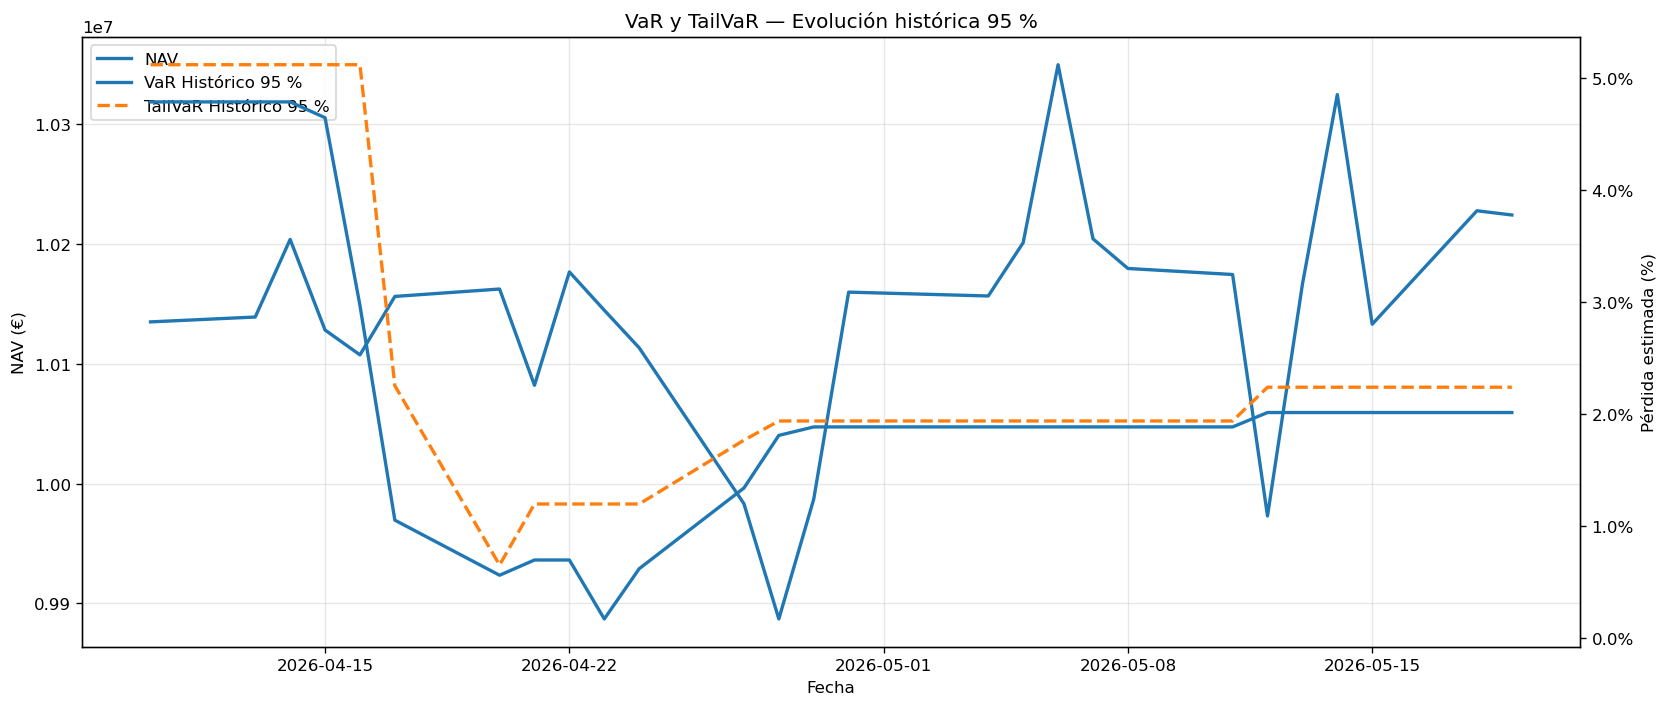

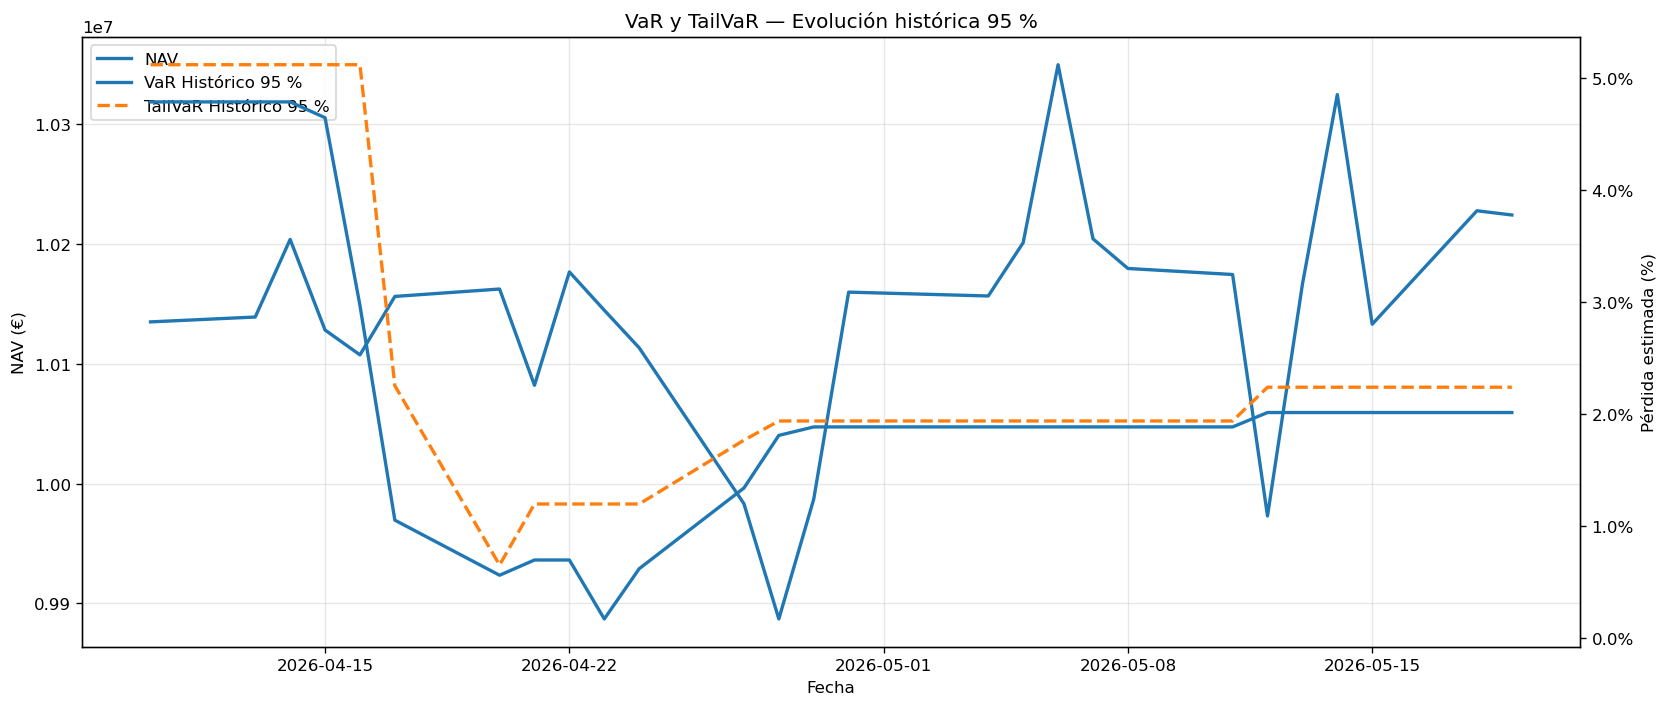

In [7]:
# ===========================================================================
# 3. VaR y TailVaR HISTÓRICO rolling — 95 %
# ===========================================================================

df_rolling_95 = vf.calcular_var_rolling(
    retornos=retornos,
    ventana=VENTANA,
    nivel_confianza=0.95,
    horizonte=HORIZONTE,
)

print("Serie rolling 95 %:")
print(df_rolling_95.map(lambda x: f"{x:.2%}" if pd.notna(x) else "N/A").tail())


# ===========================================================================
# 4. Gráfico de evolución histórica — NAV + VaR/TailVaR rolling 95 %
# ===========================================================================

%matplotlib inline

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display
import pandas as pd

# Asegurar que NAV sea una Serie
if isinstance(nav, pd.DataFrame):
    nav_plot = nav.iloc[:, 0].copy()
else:
    nav_plot = nav.copy()

# Asegurar índices datetime
nav_plot.index = pd.to_datetime(nav_plot.index)
df_rolling_95.index = pd.to_datetime(df_rolling_95.index)

# Alinear NAV al rango de fechas del rolling
nav_plot = nav_plot.loc[
    (nav_plot.index >= df_rolling_95.index.min()) &
    (nav_plot.index <= df_rolling_95.index.max())
]

# Crear figura
fig, ax1 = plt.subplots(figsize=(14, 6), dpi=120)

# NAV
ax1.plot(
    nav_plot.index,
    nav_plot.values,
    label="NAV",
    linewidth=2,
)

ax1.set_xlabel("Fecha")
ax1.set_ylabel("NAV (€)")
ax1.grid(True, alpha=0.3)

# Eje secundario para VaR y TailVaR
ax2 = ax1.twinx()

ax2.plot(
    df_rolling_95.index,
    df_rolling_95["VaR Hist"] * 100,
    label="VaR Histórico 95 %",
    linewidth=2,
)

ax2.plot(
    df_rolling_95.index,
    df_rolling_95["TailVaR Hist"] * 100,
    label="TailVaR Histórico 95 %",
    linewidth=2,
    linestyle="--",
)

ax2.set_ylabel("Pérdida estimada (%)")
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}%"))

# Leyenda conjunta
lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()

ax1.legend(
    lineas1 + lineas2,
    etiquetas1 + etiquetas2,
    loc="best",
)

plt.title("VaR y TailVaR — Evolución histórica 95 %")
fig.tight_layout()

display(fig)
plt.show()

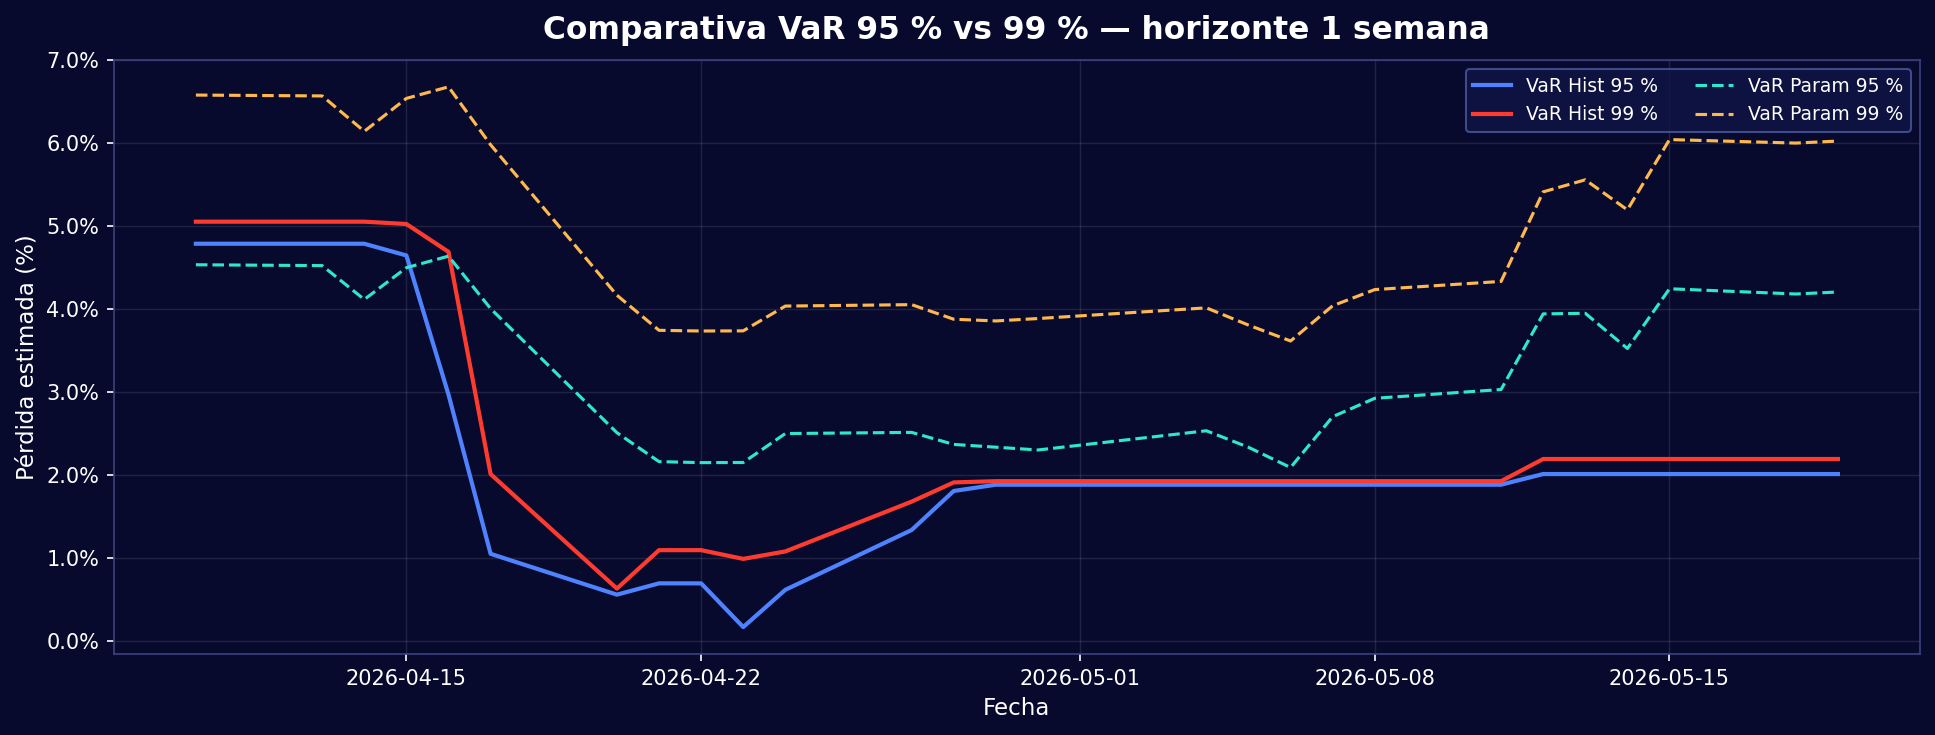

In [8]:
# ===========================================================================
# 5. Comparativa 95 % vs 99 % (solo VaR histórico)
# ===========================================================================
df_rolling_99 = vf.calcular_var_rolling(
    retornos          = retornos,
    ventana           = VENTANA,
    nivel_confianza   = 0.99,
    horizonte         = HORIZONTE,
)

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fondo   = "#070A2D"
fig, ax = plt.subplots(figsize=(13, 5), dpi=150)
fig.patch.set_facecolor(fondo)
ax.set_facecolor(fondo)
ax.grid(True, color="white", alpha=0.10, linewidth=0.7)
ax.tick_params(colors="white", labelsize=10)
for sp in ax.spines.values():
    sp.set_color("#3D4280")

ax.plot(df_rolling_95.index, df_rolling_95["VaR Hist"] * 100,
        color="#4F82FF", linewidth=2, label="VaR Hist 95 %")
ax.plot(df_rolling_99.index, df_rolling_99["VaR Hist"] * 100,
        color="#FF3B30", linewidth=2, label="VaR Hist 99 %")
ax.plot(df_rolling_95.index, df_rolling_95["VaR Param"] * 100,
        color="#2FE6D0", linewidth=1.5, linestyle="--", label="VaR Param 95 %")
ax.plot(df_rolling_99.index, df_rolling_99["VaR Param"] * 100,
        color="#FFB84D", linewidth=1.5, linestyle="--", label="VaR Param 99 %")

ax.set_title("Comparativa VaR 95 % vs 99 % — horizonte 1 semana",
             color="white", fontsize=15, fontweight="bold", pad=10)
ax.set_ylabel("Pérdida estimada (%)", color="white", fontsize=11)
ax.set_xlabel("Fecha", color="white", fontsize=11)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}%"))

leg = ax.legend(frameon=True, fontsize=9, ncol=2)
leg.get_frame().set_facecolor("#101545")
leg.get_frame().set_edgecolor("#4D5AA0")
for t in leg.get_texts():
    t.set_color("white")

plt.tight_layout()
plt.show()

In [9]:
# ===========================================================================
# 6. Resumen estadístico del VaR/TailVaR rolling
# ===========================================================================
resumen = pd.concat([
    df_rolling_95.describe().T.add_suffix(" (95%)"),
    df_rolling_99.describe().T.add_suffix(" (99%)"),
], axis=1)

# Ordenar columnas para mejor lectura
cols_95 = [c for c in resumen.columns if "95%" in c]
cols_99 = [c for c in resumen.columns if "99%" in c]
resumen = resumen[cols_95 + cols_99]

print("Estadísticas del VaR/TailVaR rolling (horizonte 1 semana):")
resumen.applymap(lambda x: f"{x:.2%}" if pd.notna(x) else 'N/A')

Estadísticas del VaR/TailVaR rolling (horizonte 1 semana):


/var/folders/59/cqdr4_cs2zx5gbpnbbx5wkfh0000gn/T/ipykernel_26514/3672154571.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  resumen.applymap(lambda x: f"{x:.2%}" if pd.notna(x) else 'N/A')


,count (95%),mean (95%),std (95%),min (95%),25% (95%),50% (95%),75% (95%),max (95%),count (99%),mean (99%),std (99%),min (99%),25% (99%),50% (99%),75% (99%),max (99%)
VaR Param,2700.00%,3.22%,0.94%,2.09%,2.35%,2.92%,4.15%,4.64%,2700.00%,4.88%,1.13%,3.61%,3.88%,4.23%,6.01%,6.68%
TailVaR Param,2700.00%,4.24%,1.05%,3.02%,3.28%,3.73%,5.31%,5.89%,2700.00%,5.71%,1.23%,4.37%,4.65%,4.98%,6.93%,7.69%
VaR Hist,2700.00%,2.07%,1.29%,0.17%,1.57%,1.88%,2.01%,4.79%,2700.00%,2.37%,1.34%,0.63%,1.92%,1.92%,2.19%,5.05%
TailVaR Hist,2700.00%,2.44%,1.36%,0.65%,1.94%,1.94%,2.24%,5.12%,2700.00%,2.44%,1.36%,0.65%,1.94%,1.94%,2.24%,5.12%
